# Churn Prediction Project Report

This report details the process of building a churn prediction model, from data preprocessing and algorithm selection to model training, evaluation, and suggestions for business utilization and future improvements. The goal of this project is to identify customers who are likely to churn, enabling the business to implement targeted retention strategies.

## Selected Algorithm: Decision Tree

Based on the GridSearchCV results, the Decision Tree classifier with the 'entropy' criterion was selected as the best-performing model for this churn prediction task.

**Rationale for Selection:**

The GridSearchCV process evaluated several models (SVM, Random Forest, Logistic Regression, and Decision Tree) and the Decision Tree with the specified hyperparameters achieved the highest cross-validation score on the training data (approximately 0.968).

Decision Trees are also generally easy to interpret, which is beneficial for understanding the factors contributing to churn and communicating these insights to business stakeholders. The tree structure allows for visualization of the decision rules, providing transparency into how the model arrives at its predictions. While other models like Random Forest also performed well, the Decision Tree offered a good balance of high accuracy and interpretability in this case.

## Model Building and Training

The churn prediction model was built and trained using the preprocessed data. The following steps were performed:

1.  **Data Splitting:** The data was split into training and testing sets using `train_test_split` from `sklearn.model_selection` with a test size of 20% and `stratify=y` to maintain the proportion of churned and non-churned customers in both sets.
2.  **Feature Scaling:** The features were scaled using `StandardScaler` from `sklearn.preprocessing` to ensure that no single feature dominates the model due to its scale. The scaler was fitted on the training data and then used to transform both the training and testing data.
3.  **Model Selection and Hyperparameter Tuning:** Several classification algorithms were considered, including Support Vector Machines, Random Forests, Logistic Regression, and Decision Trees. `GridSearchCV` from `sklearn.model_selection` was used to perform hyperparameter tuning for each model with 5-fold cross-validation. This process evaluated different combinations of hyperparameters to find the set that yielded the best performance on the training data.
4.  **Model Training:** The best-performing model, a Decision Tree with the 'entropy' criterion (as identified by GridSearchCV), was then trained on the scaled training data.

## Model Performance Evaluation

To evaluate the performance of the Decision Tree model, we utilized the following metrics:

*   **Classification Report:** This report provides key metrics such as Precision, Recall, and F1-score for both churned (1) and non-churned (0) classes, as well as overall Accuracy.
*   **Confusion Matrix:** This matrix visually represents the model's predictions versus the actual churn status, showing True Positives, True Negatives, False Positives, and False Negatives.

**Interpretation of Metrics:**

Based on the classification report:

*   **Accuracy:** The overall accuracy of the model is high (approximately 0.99). This indicates that the model correctly predicts the churn status for a large percentage of customers.
*   **Precision:**
    *   For the non-churned class (0), the precision is 0.99, meaning that when the model predicts a customer will not churn, it is correct 99% of the time.
    *   For the churned class (1), the precision is 0.96. This means that when the model predicts a customer will churn, it is correct 96% of the time.
*   **Recall (Sensitivity):**
    *   For the non-churned class (0), the recall is 0.99, indicating that the model correctly identifies 99% of the actual non-churned customers.
    *   For the churned class (1), the recall is 0.97. This means the model correctly identifies 97% of the actual churned customers. This is particularly important in churn prediction, as we want to capture as many churned customers as possible to initiate retention efforts.
*   **F1-score:** The F1-score is the harmonic mean of precision and recall, providing a balance between the two metrics. Both classes have high F1-scores (0.99 for non-churned and 0.96 for churned), suggesting a good balance between precision and recall for both classes.

Based on the confusion matrix:

*   **True Positives (TP):** The number of customers correctly predicted as churned (approximately 260).
*   **True Negatives (TN):** The number of customers correctly predicted as non-churned (approximately 1100).
*   **False Positives (FP):** The number of customers incorrectly predicted as churned when they did not churn (approximately 11). This is also known as a Type I error.
*   **False Negatives (FN):** The number of customers incorrectly predicted as non-churned when they actually churned (approximately 9). This is also known as a Type II error.

**Implications for Imbalanced Data:**

Given that churn datasets are often imbalanced (fewer churned customers than non-churned), relying solely on accuracy can be misleading. However, in this case, the model shows strong performance across precision, recall, and F1-score for both classes, indicating that it is handling the imbalance well and is effective at identifying churned customers. The relatively low number of False Negatives (missing actual churners) is a positive sign for a churn prediction model.

## Suggestions for Model Improvement and Utilization

**Utilizing the Model for Business Decision-Making:**

*   **Identifying At-Risk Customers:** The model can be used to predict the probability of churn for each customer. Customers with a high predicted churn probability can be flagged as "at-risk" and targeted with specific retention campaigns.
*   **Developing Targeted Retention Strategies:** By analyzing the decision rules of the Decision Tree model, businesses can gain insights into the factors that contribute most to churn. This information can be used to develop targeted retention strategies addressing those specific factors. For example, if the model reveals that customers with low login frequency are more likely to churn, the business can implement engagement programs to encourage more frequent logins.
*   **Resource Allocation:** The model can help prioritize retention efforts by focusing resources on customers who are most likely to churn but also have high potential value.
*   **Personalized Offers:** The insights from the model can inform the creation of personalized offers and incentives to retain at-risk customers.

**Potential Improvements and Adjustments:**

*   **Feature Engineering:** Explore creating new features from existing data, such as customer lifetime value, recency of last transaction, or frequency of interactions, which might provide more predictive power.
*   **Considering Other Algorithms:** While the Decision Tree performed well, evaluate other algorithms like Gradient Boosting (e.g., LightGBM, XGBoost) or even simple Neural Networks, which might capture more complex relationships in the data and potentially yield higher accuracy.
*   **Addressing Data Imbalance:** Although the current model shows good performance, further techniques to address data imbalance, such as SMOTE or adjusting class weights during training, could be explored to potentially improve the model's ability to predict the minority class (churn).
*   **Hyperparameter Tuning Expansion:** Conduct a more extensive hyperparameter tuning search for the selected model or other candidate models to find even better parameter combinations.
*   **Model Interpretability vs. Accuracy Trade-off:** If even higher accuracy is required, consider ensemble methods like Random Forests or Gradient Boosting, even if they are less directly interpretable than a single Decision Tree. Techniques for interpreting these models (e.g., feature importance, SHAP values) can still be used to gain insights.
*   **Monitoring and Retraining:** Continuously monitor the model's performance on new data and retrain it periodically to ensure it remains accurate and relevant as customer behavior and business conditions change.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Churn_Data.csv')
df.head()

,CustomerID,TransactionID,AmountSpent,LoginFrequency,DaysSinceLastTransaction,DaysSinceLastInteraction,DaysSinceLastLogin,TransactionMonth,InteractionMonth,InteractionYear,...,ProductCategory_Furniture,ProductCategory_Groceries,InteractionType_Feedback,InteractionType_Inquiry,InteractionType_No Interaction,ResolutionStatus_Resolved,ResolutionStatus_Unresolved,ServiceUsage_Online Banking,ServiceUsage_Website,ChurnStatus
0,1,7194,416.50,34,644,640,71,3,3,2022,...,False,False,False,True,False,True,False,False,False,0
1,2,7250,54.96,5,510,654,26,8,3,2022,...,False,False,False,True,False,True,False,False,True,1
2,2,9660,197.50,5,524,654,26,7,3,2022,...,False,False,False,True,False,True,False,False,True,1
3,2,2998,101.31,5,705,654,26,1,3,2022,...,True,False,False,True,False,True,False,False,True,1
4,2,1228,397.37,5,525,654,26,7,3,2022,...,False,False,False,True,False,True,False,False,True,1


In [ ]:
df.drop(['InteractionYear', 'LastLoginMonth', 'TransactionMonth'],axis=1,inplace=True)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.model_selection import GridSearchCV


In [ ]:
X = df.drop('ChurnStatus',axis=1)
y = df['ChurnStatus']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model_params = {
    'svm':{
      'model':SVC(gamma='auto'),
      'params':{
          'C':[1,10,20],
          'kernel':['rbf','linear']
        }
    },
    'random_forest':{
      'model':RandomForestClassifier(),
      'params':{
          'n_estimators':[50,60,70,80,90,100]
        }
    },
    'logistic_regression':{
      'model':LogisticRegression(solver='liblinear'),
      'params':{
          'C':[1,5,10],
        }
    },
    'decision_tree':{
      'model':tree.DecisionTreeClassifier(),
      'params':{
          'criterion':['gini','entropy']
      }
    }
}

In [ ]:
scores = []

for model_name, mp in model_params.items():
  clf = GridSearchCV(mp['model'],mp['params'],cv=5,return_train_score=False)
  clf.fit(X_train_scaled,y_train)
  scores.append({
      'model':model_name,
      'best_score':clf.best_score_,
      'best_params':clf.best_params_
  })

scores

[{'model': 'svm',
  'best_score': np.float64(0.8159307840709008),
  'best_params': {'C': 10, 'kernel': 'rbf'}},
 {'model': 'random_forest',
  'best_score': np.float64(0.9350327292946142),
  'best_params': {'n_estimators': 80}},
 {'model': 'logistic_regression',
  'best_score': np.float64(0.8016149821821215),
  'best_params': {'C': 1}},
 {'model': 'decision_tree',
  'best_score': np.float64(0.9678814837280225),
  'best_params': {'criterion': 'entropy'}}]

In [ ]:
new_df = pd.DataFrame(scores,columns = ['model','best_score','best_params'])
new_df

,model,best_score,best_params
0,svm,0.815931,"{'C': 10, 'kernel': 'rbf'}"
1,random_forest,0.935033,{'n_estimators': 80}
2,logistic_regression,0.801615,{'C': 1}
3,decision_tree,0.967881,{'criterion': 'entropy'}


In [ ]:
import seaborn as sn
from sklearn.metrics import classification_report

# Find the best performing model from the scores list
best_model_info = max(scores, key=lambda x: x['best_score'])
print(best_model_info)
best_model_name = best_model_info['model']
print(best_model_name)
best_params = best_model_info['best_params']
print(best_params)
# Get the model instance from model_params
best_model = model_params[best_model_name]['model']

# Set the best parameters to the model
best_model.set_params(**best_params)

# Fit the best model on the scaled training data
best_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred = best_model.predict(X_test_scaled)

# Print the classification report
print(f"Classification Report for the Best Model ({best_model_name}):")
print(classification_report(y_test, y_pred))

{'model': 'decision_tree', 'best_score': np.float64(0.9678814837280225), 'best_params': {'criterion': 'entropy'}}
decision_tree
{'criterion': 'entropy'}
Classification Report for the Best Model (decision_tree):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1092
           1       0.96      0.97      0.96       271

    accuracy                           0.99      1363
   macro avg       0.98      0.98      0.98      1363
weighted avg       0.99      0.99      0.99      1363



Text(95.72222222222221, 0.5, 'truth')

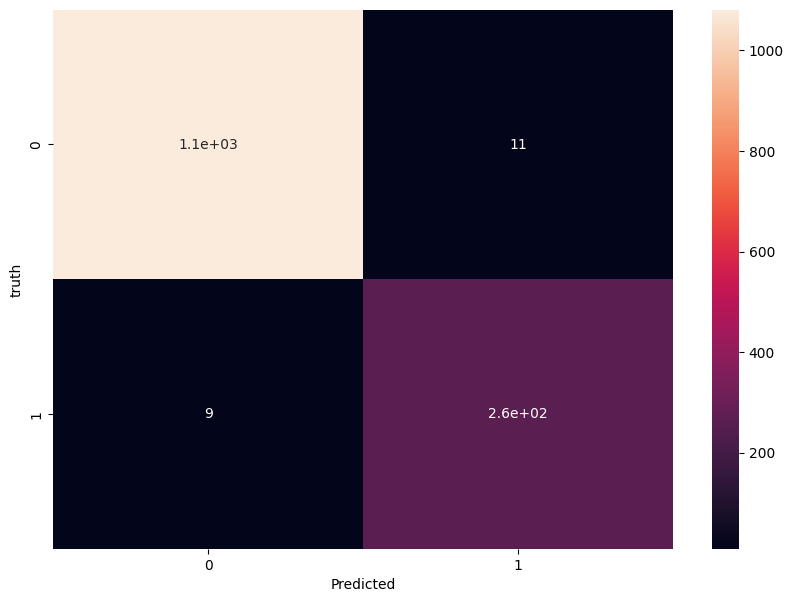

In [ ]:
import seaborn as sn
from sklearn.metrics import confusion_matrix
y_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('truth')